## **0. Initialization**

### **Installation**
LoopDetectR is on CRAN and can be installed within R by

In [ ]:
# Before running the R code cells in jupyter notebook,
# initialize the R kernel by this line of code:
# IRkernel::installspec()

In [ ]:
# Download and install
install.packages("LoopDetectR")

Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'LoopDetectR' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


In [ ]:
install.packages("deSolve")  # if not already installed
install.packages("numDeriv") # if not already installed

Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'deSolve' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'numDeriv' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


In [1]:
# Load package
library("LoopDetectR")
library(deSolve)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
colors <- c('#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB')

## **1. Model definition**

Model 2: Model for Complex Formation 

Varusai TM, Kolch W, Kholodenko BN, Nguyen LK (2015) Protein-protein interactions
generate hidden feedback and feed-forward loops to trigger bistable switches, oscillations
and biphasic dose-responses. Molecular bioSystems 11: 2750-2762.

Supplement Data Table S4 is for Model 3.


In [3]:
func_varusai15_simple <- function(t,x,params){
    # function: Complex Formation [Varusai et al., 2015]
    #
    # Varusai TM, Kolch W, Kholodenko BN, Nguyen LK (2015) Protein-protein interactions
    # generate hidden feedback and feed-forward loops to trigger bistable switches, oscillations
    # and biphasic dose-responses. Molecular bioSystems 11: 2750-2762.
    #
    dx <- rep(0,3)
    dx[1] <- -params[1] * x[1] * x[2] + params[2]* x[3];
    dx[2] <- -params[1] * x[1] * x[2] + params[2]* x[3];
    dx[3] <- params[1] * x[1] * x[2] - params[2]* x[3];
    return(dx)
}

## **2. Result reproduction**

### **2.1. Loop structures**

In [68]:
# Parameters from supplementary material
params <- c(1.0, 2.0)
s_star <- c(10.0, 5.0, 2.0) # Dummy steady state for initialization

# Parameters not yet in supplement data
perturbation_point <- 0.2

In [69]:
# compute loops
res_tab <- find_loops_vset(func_varusai15_simple,vset=list(s_star),t=1,params=params,max_num_loops=10)
# The loop list is reported
res_tab$loop_rep[[1]] 
# To access a specific loop representation: e.g., the sixth loop, add [6,]

loop,length,sign
<I<list>>,<dbl>,<dbl>
"1, 1",1,-1
"2, 2",1,-1
"3, 3",1,-1
"1, 2, 1",2,1
"1, 3, 1",2,1
"1, 3, 2, 1",3,-1
"2, 3, 1, 2",3,-1
"2, 3, 2",2,1


In [6]:
loop_summary(res_tab$loop_rep[[1]])

,len_1,len_2,len_3
,<dbl>,<dbl>,<dbl>
all,3,3,2
pos,0,3,0
neg,3,0,2


In [7]:
# Index of node of interest
noi <- 2 
# Return all loops from loop_list containing node 2
loop_list <- res_tab$loop_rep[[1]]
loop_list[vapply(loop_list$loop,function(x){noi %in% x},logical(1)),]

,loop,length,sign
,<I<list>>,<dbl>,<dbl>
2,"2, 2",1,-1
4,"1, 2, 1",2,1
6,"1, 3, 2, 1",3,-1
7,"2, 3, 1, 2",3,-1
8,"2, 3, 2",2,1


### **2.2. Calculating the Jacobian matrix**

Sign jacobian matrix can be access via `res_tab` variable that we have calculated above, or derived from a jacobian matrix at a specific state

In [8]:
res_tab

loop,length,sign
<I<list>>,<dbl>,<dbl>
"1, 1",1,-1
"2, 2",1,-1
"3, 3",1,-1
"1, 2, 1",2,1
"1, 3, 1",2,1
"1, 3, 2, 1",3,-1
"2, 3, 1, 2",3,-1
"2, 3, 2",2,1
-1,-1,1


In [9]:
# The corresponding signed Jacobian matrix
res_tab$jac_rep[[1]]

-1,-1,1
-1,-1,1
1,1,-1


The function jacobian from the numDeriv package can be used to determine numerically the Jacobian matrix of an ODE system at a certain set of values for the variables, `s_star`. The approach is that of finite differences (with real step) or complex step approach, the latter of which is supposed to deliver more exact results [Martins et al., 2003].

In [37]:
# The function func_POSm4 returns a vector, but deSolve needs the vector within
# a list as output. Therefore, we define a function that simply puts the output 
# of func_POSm4 into a list:
func_list <- function(t,x,params){list(func_varusai15_simple(t,x,params))}
sol <-  deSolve::ode(y = s_star, times = seq(0,1,0.001), func = func_list, 
                     parms=params)

# Set the last point of the numeric solution as point of interest, omit the 
# first column (it contains the time)
s_star_end <- sol[dim(sol)[1],2:dim(sol)[2]]
s_star_end

1        2        3 
6.623565 1.623565 5.376435

In [11]:
j_matrix <- numDeriv::jacobian(func_varusai15_simple,s_star,method="complex",
                               t=1,params=params)
j_matrix

-5,-10,2
-5,-10,2
5,10,-2


In [12]:
signed_jacobian <- sign(j_matrix)
signed_jacobian

-1,-1,1
-1,-1,1
1,1,-1


### **2.3. Temporal dynamics**

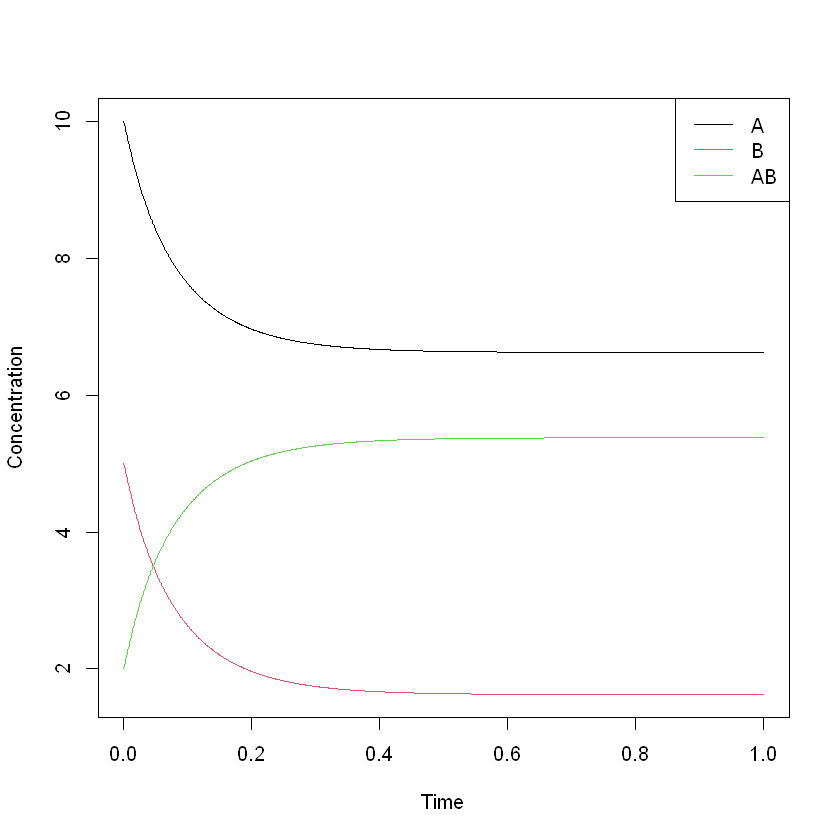

In [13]:
matplot(
  sol[,1], sol[,2:4],
  type = "l",
  lty = 1,
  xlab = "Time",
  ylab = "Concentration",
)

legend(
  "topright",
  legend = c("A", "B", "AB"),
  col = 1:3,
  lty = 1
)

In [38]:
sol_for_plot <- as.data.frame(sol)

# rename columns for clarity
colnames(sol_for_plot) <- c("time", "A", "B", "AB")

# reshape to long format
sol_long <- sol_for_plot %>%
  pivot_longer(cols = A:AB, names_to = "species", values_to = "value")

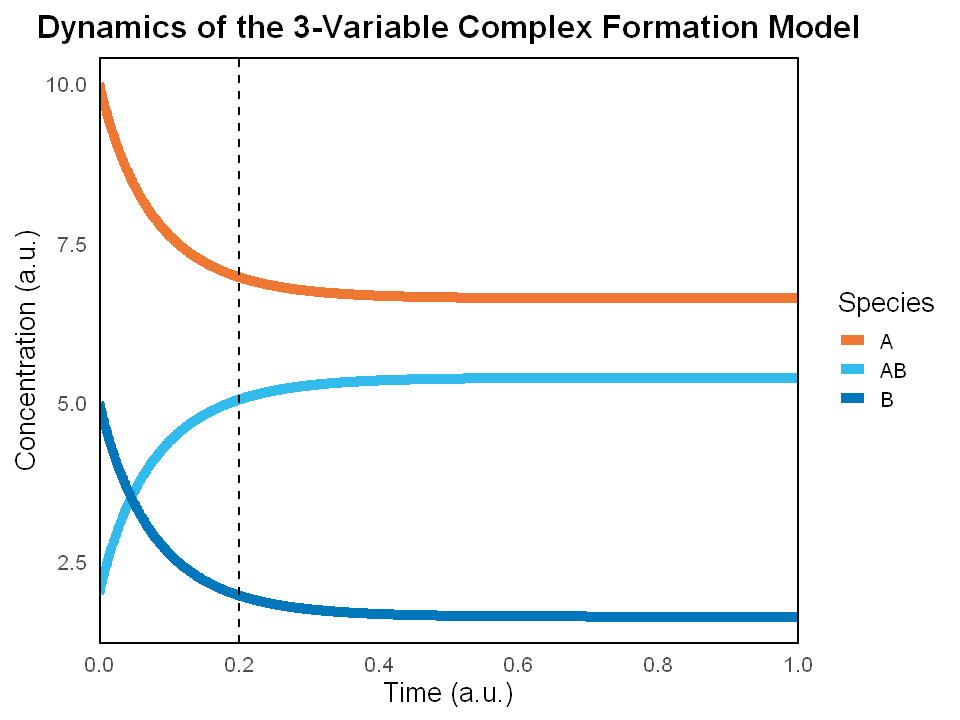

In [39]:
options(repr.plot.width = 8, repr.plot.height = 6)
colors <- c(
  A = "#EE7733",
  B = "#0077BB",
  AB = "#33BBEE"
)

plot1 <- ggplot(sol_long, aes(x = time, y = value, colour = species)) +
  geom_line(size = 3) +
  ## vertical dashed line
  geom_vline(
    xintercept = perturbation_point,
    linetype = "dashed",
    colour = "black",
    linewidth = 0.7
  ) +
  scale_colour_manual(values = colors) + # scale_colour_brewer(palette = "Dark2") +
  scale_x_continuous(
    breaks = seq(0, 1, 0.2),
    minor_breaks = seq(0, 1, 0.1),
    limits = c(0, 1),
    expand = c(0, 0)
  ) +
  coord_cartesian(xlim = c(0, 1), clip = "on") +
  scale_y_continuous(
    minor_breaks = seq(0, 11, 2),
  ) +
  labs(
    title = "Dynamics of the 3-Variable Complex Formation Model",
    x = "Time (a.u.)",
    y = "Concentration (a.u.)",
    colour = "Species"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    # panel.grid.minor = element_blank(),
    panel.grid = element_blank(),

    ## black outer box
    panel.border = element_rect(
      colour = "black",
      fill = NA,
      linewidth = 1.1
    )
  )

plot1
# ggsave("POSm4_plot.png", plot1, width = 10, height = 8, units = "in", dpi = 300)

### **2.4. Pertubation Analysis**

#### **2.4.1. Partubation in A**

In [48]:
# Size of variable sol (how many rows and columns)
dim(sol)
object.size(sol)

[1] 1001    4

33904 bytes

In [49]:
t0 <- 0.2          # perturbation time in original time axis
idx0 <- 200
cap <- 0.05        # window half-width (before/after), like Python cap_range
dt   <- 0.001

In [41]:
# pre-perturbation window from the already-simulated sol
k <- round(cap / dt)
pre  <- sol[(idx0 - k):idx0, 2:4, drop = FALSE]
tpre <- seq(-cap, 0, by = dt)

# perturbed IC and forward simulation on local time [0, cap]
y0 <- as.numeric(sol[idx0, 2:4])
y0[1] <- 40.0

In [42]:
200-cap/dt

[1] 150

In [43]:
s_star_pertubation_1 <- as.numeric(sol[(200-cap/dt),2:4])
tpre = seq(-cap, 0, by = dt)
sol_pertubation_1_pre  <-  deSolve::ode(y = s_star_pertubation_1, times = tpre, func = func_list, 
                     parms=params)

s_star_pertubation_1 <- as.numeric(sol[200,2:4])
# Change the 1st position to 40.0
s_star_pertubation_1[1] <- 40.0

tpost <- seq(0, cap, by = dt)
sol_pertubation_1_post  <-  deSolve::ode(y = s_star_pertubation_1, times = tpost, func = func_list, 
                     parms=params)

In [ ]:
t_all <- c(tpre, tpost)
y_all <- rbind(sol_pertubation_1_pre, sol_pertubation_1_post)   # avoid duplicating t=0 row
labels <- c("A", "B", "AB")

# Plot: 4 stacked panels (base graphics)

# To save as PNG file, uncomment the following lines, and the dev.off() line at the end

# png(
#   filename = "model_2_perturbation_A.png",
#   width = 8, height = 6, units = "in",
#   res = 300          # DPI
# )

op <- par(mfrow = c(3,1), mar = c(4,5,3,1))
for (j in 2:4) {
  plot(t_all, y_all[,j], type = "l", lwd = 4, col = colors[j-1],
       xlab = "Time", ylab = paste("Concentration of", labels[j-1], sep=""),
       xlim = c(-0.05, 0.05), xaxt = "n", xaxs = "i",
       main = paste("Perturbation Analysis: ", labels[j-1], " when A is perturbed", sep=""))
  axis(
    1,
    at = seq(-0.05, 0.05, by = 0.01)
  )
  abline(v = 0, lty = 2, lwd = 2)
  box(lwd = 2)   # black outer box
}

# dev.off()
par(op)

agg_record_1372292667 
                    2

In [46]:
s_star_pertubation_1 <- as.numeric(sol[(200-cap/dt),2:4])
tpre = seq(-cap, 0, by = dt)
sol_pertubation_1_pre  <-  deSolve::ode(y = s_star_pertubation_1, times = tpre, func = func_list, 
                     parms=params)

s_star_pertubation_1 <- as.numeric(sol[200,2:4])
# Change the 2nd position to 10.0
s_star_pertubation_1[2] <- 10.0

tpost <- seq(0, cap, by = dt)
sol_pertubation_1_post  <-  deSolve::ode(y = s_star_pertubation_1, times = tpost, func = func_list, 
                     parms=params)

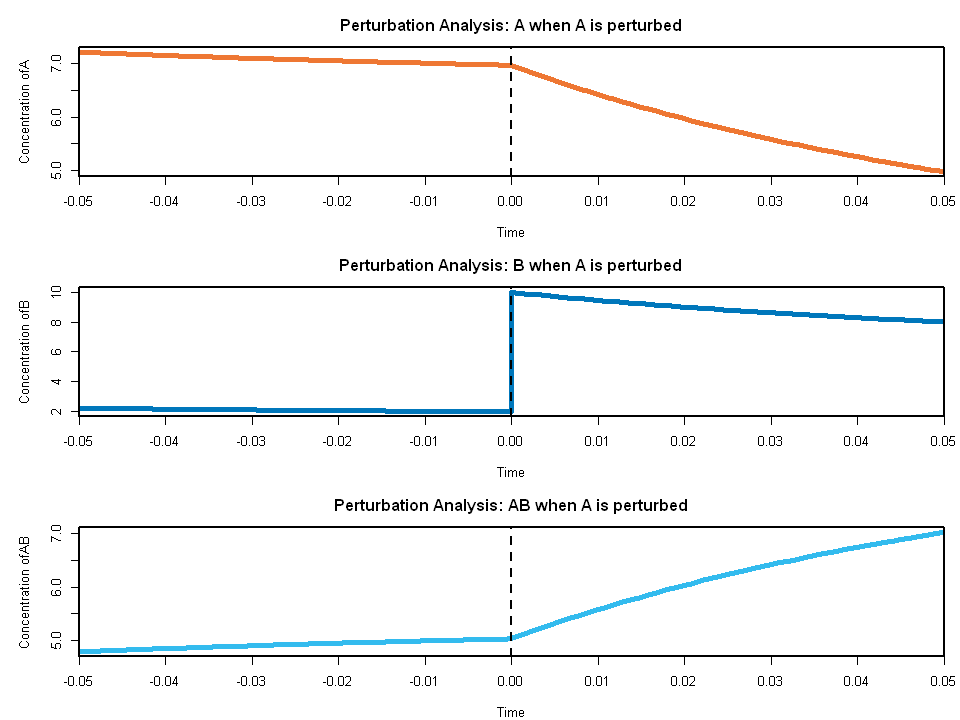

In [47]:
t_all <- c(tpre, tpost)
y_all <- rbind(sol_pertubation_1_pre, sol_pertubation_1_post)   # avoid duplicating t=0 row
labels <- c("A", "B", "AB")

# Plot: 4 stacked panels (base graphics)

# To save as PNG file, uncomment the following lines, and the dev.off() line at the end

# png(
#   filename = "model_2_perturbation_B.png",
#   width = 8, height = 6, units = "in",
#   res = 300          # DPI
# )

op <- par(mfrow = c(3,1), mar = c(4,5,3,1))
for (j in 2:4) {
  plot(t_all, y_all[,j], type = "l", lwd = 4, col = colors[j-1],
       xlab = "Time", ylab = paste("Concentration of", labels[j-1], sep=""),
       xlim = c(-0.05, 0.05), xaxt = "n", xaxs = "i",
       main = paste("Perturbation Analysis: ", labels[j-1], " when A is perturbed", sep=""))
  axis(
    1,
    at = seq(-0.05, 0.05, by = 0.01)
  )
  abline(v = 0, lty = 2, lwd = 2)
  box(lwd = 2)   # black outer box
}

# dev.off()
par(op)

## **3. Additional features**

### **3.1. Add subject ID to make the loop result more comprehensible**

In [57]:
id_to_subject <- c(
  "A", "B", "AB"
)
names(id_to_subject) <- 1:3

In [58]:
df <- res_tab$loop_rep[[1]]

In [59]:
df$loop_subject <- lapply(
  df$loop,
  function(t) unname(id_to_subject[as.character(t)])
)


In [60]:
df

loop,length,sign,loop_subject
<I<list>>,<dbl>,<dbl>,<list>
"1, 1",1,-1,"A, A"
"2, 2",1,-1,"B, B"
"3, 3",1,-1,"AB, AB"
"1, 2, 1",2,1,"A, B, A"
"1, 3, 1",2,1,"A , AB, A"
"1, 3, 2, 1",3,-1,"A , AB, B , A"
"2, 3, 1, 2",3,-1,"B , AB, A , B"
"2, 3, 2",2,1,"B , AB, B"


### **3.2. Represent regulation relationship from Jacobian matrix**

In [63]:
sign_J <- sign(j_matrix)
labs <- paste0(c("A", "B", "AB"))
rownames(sign_J) <- labs
colnames(sign_J) <- labs

regulation_info <- sign_J %>%
  as.data.frame() %>%
  mutate(from = rownames(.)) %>%
  pivot_longer(
    -from,
    names_to = "to",
    values_to = "regulation"
  ) %>%
  mutate(
    regulation_words = case_when(
      regulation == -1 ~ "inhibition (negative)",
      regulation ==  1 ~ "activation (positive)",
      TRUE             ~ "no regulation"
    )
  )
regulation_info[regulation_info$regulation != 0, ]

from,to,regulation,regulation_words
<chr>,<chr>,<dbl>,<chr>
A,A,-1,inhibition (negative)
A,B,-1,inhibition (negative)
A,AB,1,activation (positive)
B,A,-1,inhibition (negative)
B,B,-1,inhibition (negative)
B,AB,1,activation (positive)
AB,A,1,activation (positive)
AB,B,1,activation (positive)
AB,AB,-1,inhibition (negative)


### **3.3. Loop Summary in more detail**

In [64]:
df

loop,length,sign,loop_subject
<I<list>>,<dbl>,<dbl>,<list>
"1, 1",1,-1,"A, A"
"2, 2",1,-1,"B, B"
"3, 3",1,-1,"AB, AB"
"1, 2, 1",2,1,"A, B, A"
"1, 3, 1",2,1,"A , AB, A"
"1, 3, 2, 1",3,-1,"A , AB, B , A"
"2, 3, 1, 2",3,-1,"B , AB, A , B"
"2, 3, 2",2,1,"B , AB, B"


In [65]:
split_by_len <- split(df, df$length)

loop_summary_extended <- data.frame(
  length = as.numeric(names(split_by_len)),
  num_loops = vapply(split_by_len, nrow, integer(1)),
  loops = I(lapply(split_by_len, function(x) x$loop_subject)),
  stringsAsFactors = FALSE
)

loop_summary_extended$num_loops_positive <- vapply(
  split_by_len,
  function(x) sum(x$sign > 0),
  integer(1)
)

loop_summary_extended$num_loops_negative <- vapply(
  split_by_len,
  function(x) sum(x$sign < 0),
  integer(1)
)

loop_summary_extended$loops_positive <- I(lapply(
  split_by_len,
  function(x) x$loop_subject[x$sign > 0]
))

loop_summary_extended$loops_negative <- I(lapply(
  split_by_len,
  function(x) x$loop_subject[x$sign < 0]
))

loop_summary_extended <- loop_summary_extended[
  order(loop_summary_extended$length),
  c("length","num_loops","num_loops_positive","num_loops_negative",
    "loops","loops_positive","loops_negative")
]

loop_summary_extended


,length,num_loops,num_loops_positive,num_loops_negative,loops,loops_positive,loops_negative
,<dbl>,<int>,<int>,<int>,<I<named list>>,<I<named list>>,<I<named list>>
1,1,3,0,3,"c(""A"", ""....",,"c(""A"", ""...."
2,2,3,3,0,"c(""A"", ""....","c(""A"", ""....",
3,3,2,0,2,"c(""A"", ""....",,"c(""A"", ""...."
